# Exploratory Data Analysis & Visualization — UIDAI Aadhaar Enrollment Data

**Data Analyst Internship — Week 3: Exploratory Data Analysis and Visualization**

This notebook is the executable companion to `Week3_EDA_Visualization.docx`. It performs EDA on
the same cleaned dataset from Week 2 — **440,817 Aadhaar enrollment records** published by UIDAI
(Government of India) — formulating and testing 4 hypotheses, and building 6 annotated
visualizations plus an interactive summary dashboard.

**Approach:** every hypothesis is tested and reported honestly, including the ones the data does
**not** support — a supported-only report overstates what the data actually shows.


## 1. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "UIDAI.csv.gz"


## 2. Load & Clean (recap from Week 2)

In [5]:
df = pd.read_csv(DATA_PATH, dtype={"PIN": "string"}, low_memory=False)
print(f"Raw rows: {len(df):,}")

# Same cleaning steps as Week 2
df = df[(df["Age"] >= 0) & (df["Age"] <= 110)].copy()
for c in ["Registrar", "EnrolmentAgency", "State", "District", "SubDistrict", "Gender"]:
    df[c] = df[c].astype(str).str.strip()
df["Gender"] = df["Gender"].replace({"T": "Transgender", "M": "Male", "F": "Female"})

df["TotalEnrolments"] = df["AadhaarGenerated"] + df["EnrolmentRejected"]
df["RejectionRate"] = np.where(df["TotalEnrolments"] > 0, df["EnrolmentRejected"] / df["TotalEnrolments"], np.nan)

bins = [-1, 5, 12, 18, 30, 45, 60, 111]
labels = ["0-5", "6-12", "13-18", "19-30", "31-45", "46-60", "60+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

print(f"Cleaned rows: {len(df):,}")
df.head()


Raw rows: 440,818
Cleaned rows: 440,817


,Registrar,EnrolmentAgency,State,District,SubDistrict,PIN,Gender,Age,AadhaarGenerated,EnrolmentRejected,ResidentsProvidingEmail,ResidentsProvidingMobile,TotalEnrolments,RejectionRate,AgeGroup
0,Allahabad Bank,A-Onerealtors Pvt Ltd,Uttar Pradesh,Allahabad,Meja,212303,Female,7,1,0,0,1,1,0.0,6-12
1,Allahabad Bank,Asha Security Guard Services,Uttar Pradesh,Sonbhadra,Robertsganj,231213,Male,8,1,0,0,0,1,0.0,6-12
2,Allahabad Bank,SGS INDIA PVT LTD,Uttar Pradesh,Sultanpur,Sultanpur,227812,Female,13,1,0,0,1,1,0.0,13-18
3,Allahabad Bank,Sri Ramraja Sarkar Lok Kalyan Trust,Uttar Pradesh,Shamli,Shamli,247775,Male,6,1,0,0,1,1,0.0,6-12
4,Allahabad Bank,Transmoovers India,Uttar Pradesh,Gorakhpur,Sahjanwa,273001,Male,8,1,0,0,1,1,0.0,6-12


## 3. Initial Analysis — Descriptive Statistics

In [6]:
df[["Age", "AadhaarGenerated", "EnrolmentRejected"]].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,440817.0,19.704145,18.686246,0.0,5.0,13.0,30.0,106.0
AadhaarGenerated,440817.0,1.601431,3.391823,0.0,1.0,1.0,1.0,391.0
EnrolmentRejected,440817.0,0.087510,0.407088,0.0,0.0,0.0,0.0,40.0


In [7]:
print(f"Age: mean={df['Age'].mean():.2f}  median={df['Age'].median():.0f}  "
      f"std={df['Age'].std():.2f}  skew={df['Age'].skew():.3f}")


Age: mean=19.70  median=13  std=18.69  skew=1.154


The Age field is notably right-skewed (skewness ≈ 1.15) — half of all records involve
residents aged 13 or younger, immediately suggesting **child Aadhaar enrollment** as a major
share of activity, and motivating Hypothesis H1 below.

## 4. Hypothesis Formulation & Testing

| # | Hypothesis | Test |
|---|---|---|
| H1 | Rejection rate varies by age group, highest for young children | Group-wise rate comparison, 7 age bands |
| H2 | States with higher mobile-capture rate show lower rejection rates | Pearson correlation, state-level (n=37) |
| H3 | Rejection rate differs by gender | Group-wise rate comparison |
| H4 | Age is linearly correlated with rejection at the record level | Pearson correlation, row-level (n=440,817) |


In [8]:
# H1 — Rejection rate by age group
age_group_summary = df.groupby("AgeGroup", observed=True).agg(
    Generated=("AadhaarGenerated", "sum"), Rejected=("EnrolmentRejected", "sum")
)
age_group_summary["Total"] = age_group_summary.Generated + age_group_summary.Rejected
age_group_summary["RejRate"] = age_group_summary.Rejected / age_group_summary.Total
print("H1 result:")
age_group_summary


H1 result:


,Generated,Rejected,Total,RejRate
AgeGroup,,,,
0-5,291145,21647,312792,0.069206
6-12,164068,7924,171992,0.046072
13-18,44472,1922,46394,0.041428
19-30,94519,3130,97649,0.032054
31-45,59801,1679,61480,0.027310
46-60,31101,1088,32189,0.033800
60+,20832,1186,22018,0.053865


In [9]:
# H2 — State-level mobile capture rate vs rejection rate
state_summary = df.groupby("State").agg(
    Generated=("AadhaarGenerated", "sum"), Rejected=("EnrolmentRejected", "sum"),
    Mobile=("ResidentsProvidingMobile", "sum")
)
state_summary["Total"] = state_summary["Generated"] + state_summary["Rejected"]
state_summary["RejRate"] = state_summary["Rejected"] / state_summary["Total"]
state_summary["MobileRate"] = state_summary["Mobile"] / state_summary["Total"]

r_state, p_state = stats.pearsonr(state_summary["MobileRate"], state_summary["RejRate"])
print(f"H2 result: Pearson r = {r_state:.4f}, p = {p_state:.4f}, n = {len(state_summary)}")
print("Not statistically significant (p > 0.05) — H2 is NOT supported.")


H2 result: Pearson r = 0.2695, p = 0.1068, n = 37
Not statistically significant (p > 0.05) — H2 is NOT supported.


In [10]:
# H3 — Rejection rate by gender
gender_summary = df.groupby("Gender").agg(
    Generated=("AadhaarGenerated", "sum"), Rejected=("EnrolmentRejected", "sum"), Rows=("Gender", "count")
)
gender_summary["Total"] = gender_summary["Generated"] + gender_summary["Rejected"]
gender_summary["RejRate"] = gender_summary["Rejected"] / gender_summary["Total"]
print("H3 result:")
gender_summary


H3 result:


,Generated,Rejected,Rows,Total,RejRate
Gender,,,,,
Female,247732,15235,148013,262967,0.057935
Male,458200,23340,292797,481540,0.048469
Transgender,6,1,7,7,0.142857


**Caution on H3:** the Transgender rejection rate (14.3%) is based on only **7 total
enrolments** — a single-digit denominator. It is reported for completeness but should not be
compared at face value against the Male/Female rates, which rest on samples of 481,540 and
262,967 respectively.

In [11]:
# H4 — Row-level Age vs RejectionRate correlation
sub = df.dropna(subset=["RejectionRate"])
r_age, p_age = stats.pearsonr(sub["Age"], sub["RejectionRate"])
print(f"H4 result: Pearson r = {r_age:.4f}, p = {p_age:.2e}, n = {len(sub):,}")
print("Statistically significant due to large n, but practically negligible — H4 is NOT")
print("meaningfully supported (the effect size is too small to be actionable).")


H4 result: Pearson r = -0.0641, p = 0.00e+00, n = 440,817
Statistically significant due to large n, but practically negligible — H4 is NOT
meaningfully supported (the effect size is too small to be actionable).


## 5. Visualizations

### Figure 1 — Age Distribution

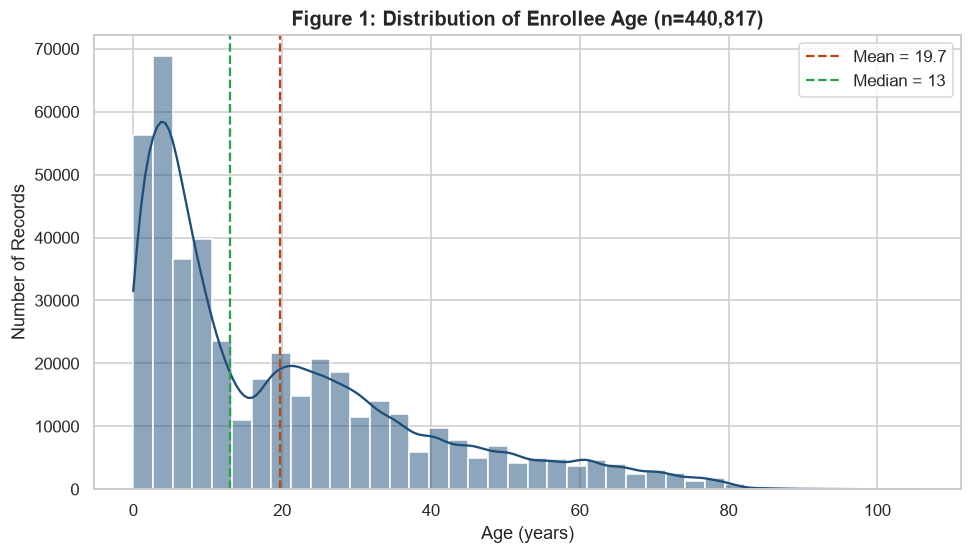

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.2))
sns.histplot(df["Age"], bins=40, color="#1F4E79", ax=ax, kde=True)
mean_age, median_age = df["Age"].mean(), df["Age"].median()
ax.axvline(mean_age, color="#B5471B", linestyle="--", linewidth=1.5, label=f"Mean = {mean_age:.1f}")
ax.axvline(median_age, color="#2E9E4F", linestyle="--", linewidth=1.5, label=f"Median = {median_age:.0f}")
ax.set_title("Figure 1: Distribution of Enrollee Age (n=440,817)", fontsize=13, fontweight="bold")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of Records")
ax.legend()
plt.tight_layout()
plt.savefig("chart1_age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### Figure 2 — Rejection Rate by Age Group

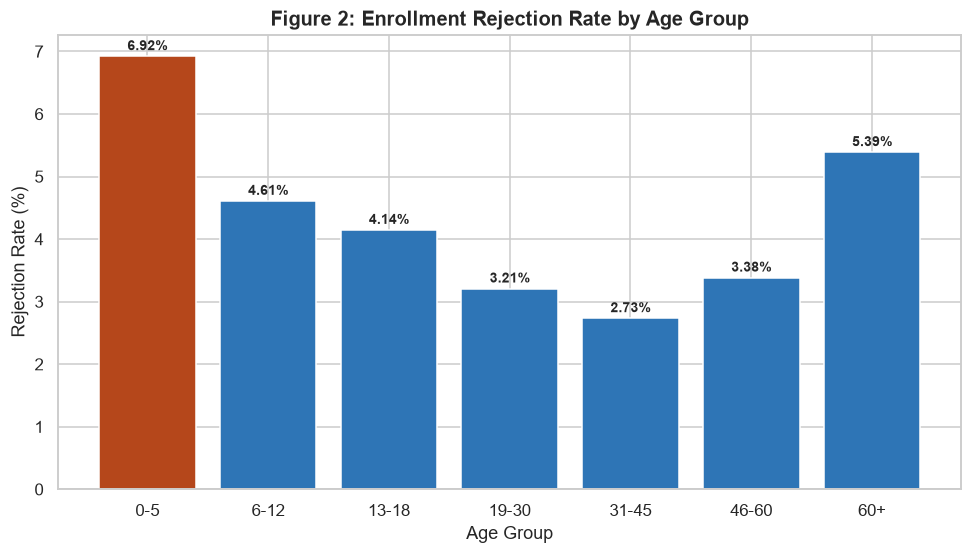

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.2))
colors = ["#B5471B" if v == age_group_summary["RejRate"].max() else "#2E75B6" for v in age_group_summary["RejRate"]]
bars = ax.bar(age_group_summary.index.astype(str), age_group_summary["RejRate"] * 100, color=colors)
for bar, val in zip(bars, age_group_summary["RejRate"] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f"{val:.2f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Figure 2: Enrollment Rejection Rate by Age Group", fontsize=13, fontweight="bold")
ax.set_xlabel("Age Group")
ax.set_ylabel("Rejection Rate (%)")
plt.tight_layout()
plt.savefig("chart2_rejection_by_agegroup.png", dpi=150, bbox_inches="tight")
plt.show()


### Figure 3 — Mobile Capture Rate vs. Rejection Rate (State Level)

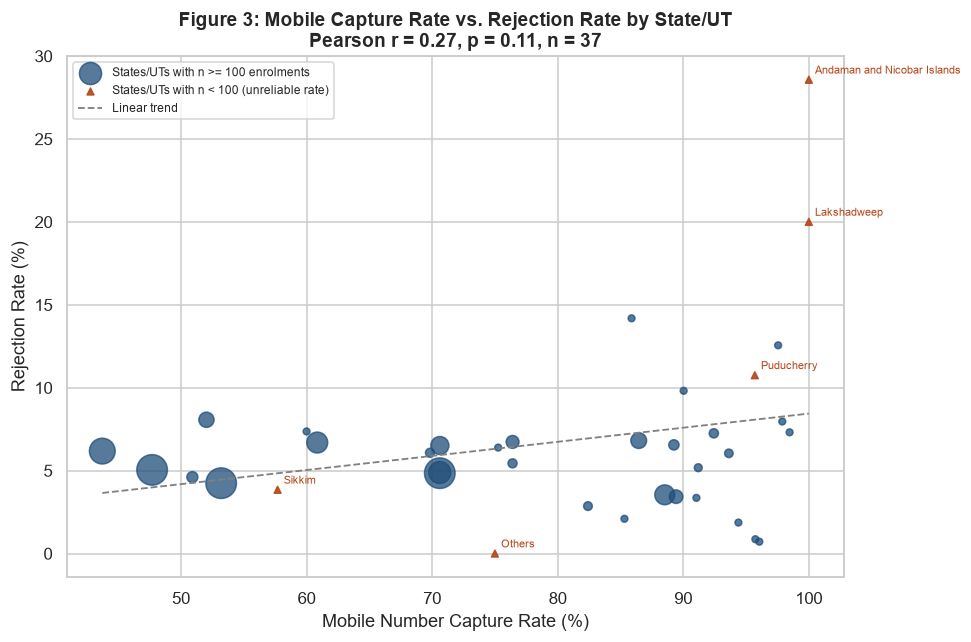

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
small_n = state_summary["Total"] < 100
sizes = np.clip(state_summary["Total"] / 200, 20, 400)
ax.scatter(state_summary.loc[~small_n, "MobileRate"] * 100, state_summary.loc[~small_n, "RejRate"] * 100,
           s=sizes[~small_n], alpha=0.75, color="#1F4E79", label="States/UTs with n >= 100 enrolments")
ax.scatter(state_summary.loc[small_n, "MobileRate"] * 100, state_summary.loc[small_n, "RejRate"] * 100,
           s=sizes[small_n], alpha=0.9, color="#B5471B", marker="^", label="States/UTs with n < 100 (unreliable rate)")
for state in state_summary[small_n].index:
    ax.annotate(state, (state_summary.loc[state, "MobileRate"]*100, state_summary.loc[state, "RejRate"]*100),
                fontsize=7, xytext=(4, 4), textcoords="offset points", color="#B5471B")
z = np.polyfit(state_summary["MobileRate"], state_summary["RejRate"], 1)
xs = np.linspace(state_summary["MobileRate"].min(), state_summary["MobileRate"].max(), 50)
ax.plot(xs*100, (z[0]*xs + z[1])*100, "--", color="grey", linewidth=1.2, label="Linear trend")
ax.set_title(f"Figure 3: Mobile Capture Rate vs. Rejection Rate by State/UT\nPearson r = {r_state:.2f}, p = {p_state:.2f}, n = {len(state_summary)}",
             fontsize=12.5, fontweight="bold")
ax.set_xlabel("Mobile Number Capture Rate (%)")
ax.set_ylabel("Rejection Rate (%)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("chart3_mobile_vs_rejection_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


### Figure 4 — Rejection Rate by Gender

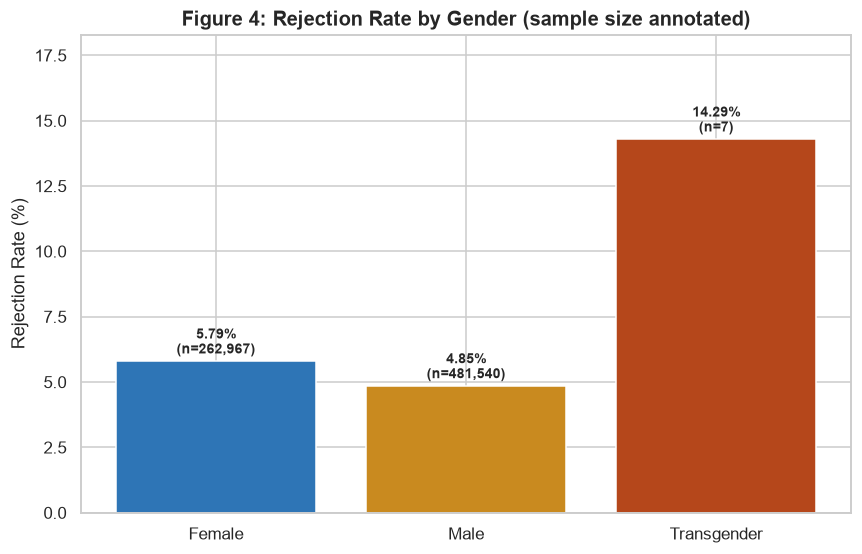

In [15]:
fig, ax = plt.subplots(figsize=(8, 5.2))
bars = ax.bar(gender_summary.index, gender_summary["RejRate"] * 100, color=["#2E75B6", "#C98A1F", "#B5471B"])
for bar, (idx, row_) in zip(bars, gender_summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, row_["RejRate"]*100 + 0.3, f"{row_['RejRate']*100:.2f}%\n(n={int(row_['Total']):,})",
            ha="center", fontsize=9, fontweight="bold")
ax.set_title("Figure 4: Rejection Rate by Gender (sample size annotated)", fontsize=13, fontweight="bold")
ax.set_ylabel("Rejection Rate (%)")
ax.set_ylim(0, gender_summary["RejRate"].max()*100 + 4)
plt.tight_layout()
plt.savefig("chart4_gender_rejection.png", dpi=150, bbox_inches="tight")
plt.show()


### Figure 5 — Correlation Matrix

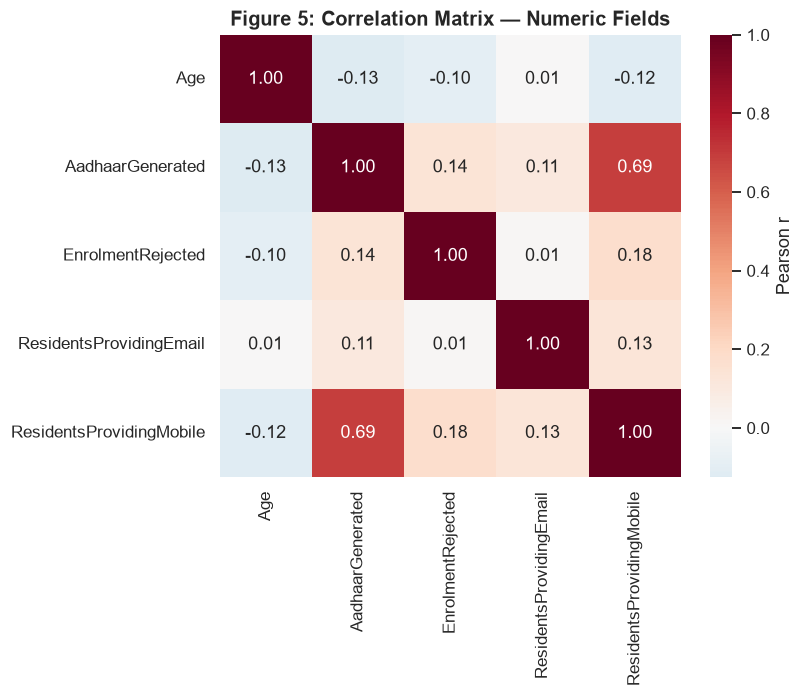

In [16]:
numeric_cols = ["Age", "AadhaarGenerated", "EnrolmentRejected", "ResidentsProvidingEmail", "ResidentsProvidingMobile"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Figure 5: Correlation Matrix — Numeric Fields", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart5_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### Figure 6 — Age Distribution by Gender

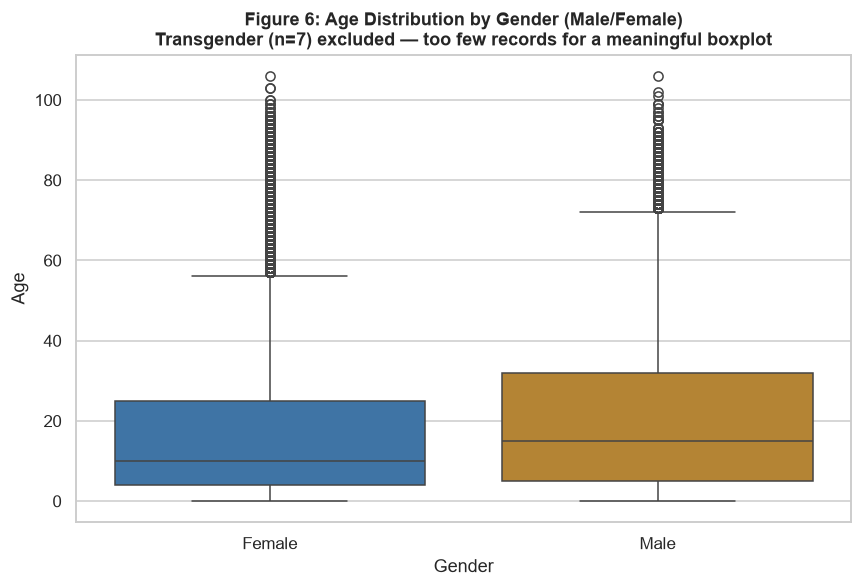

In [17]:
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_df = df[df["Gender"].isin(["Male", "Female"])]  # Transgender n=7 excluded — too few for a meaningful box
sns.boxplot(data=plot_df, x="Gender", y="Age", hue="Gender", ax=ax, palette=["#2E75B6", "#C98A1F"], legend=False)
ax.set_title("Figure 6: Age Distribution by Gender (Male/Female)\nTransgender (n=7) excluded — too few records for a meaningful boxplot",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("chart6_age_boxplot_gender.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Export Summary Data

In [18]:
import os
os.makedirs("outputs", exist_ok=True)

age_group_summary.reset_index().to_csv("outputs/age_group_summary.csv", index=False)
state_summary.reset_index().to_csv("outputs/state_summary_eda.csv", index=False)
gender_summary.reset_index().to_csv("outputs/gender_summary.csv", index=False)
corr.to_csv("outputs/correlation_matrix.csv")

hypothesis_results = pd.DataFrame([
    {"Hypothesis": "H1: Age-group rejection variation", "Statistic": "Rate range", "Value": "2.73% (31-45) to 6.92% (0-5)", "Supported": True},
    {"Hypothesis": "H2: Mobile capture vs rejection (state)", "Statistic": "Pearson r", "Value": f"{r_state:.4f} (p={p_state:.4f})", "Supported": False},
    {"Hypothesis": "H3: Gender rejection gap", "Statistic": "Rate gap", "Value": "Female 5.79% vs Male 4.85%", "Supported": "Weakly"},
    {"Hypothesis": "H4: Age vs rejection (row-level)", "Statistic": "Pearson r", "Value": f"{r_age:.4f} (p={p_age:.2e})", "Supported": "Statistically yes, practically no"},
])
hypothesis_results.to_csv("outputs/hypothesis_results.csv", index=False)

print("Saved 5 CSV files to outputs/:")
for f in os.listdir("outputs"):
    print(" -", f)


Saved 5 CSV files to outputs/:
 - age_group_summary.csv
 - correlation_matrix.csv
 - gender_summary.csv
 - hypothesis_results.csv
 - state_summary_eda.csv


## 7. Interactive Summary Dashboard

Builds a self-contained HTML dashboard (KPI cards + interactive Plotly charts) summarising the
EDA findings — fully offline, no internet connection required to view.


In [19]:
import plotly.express as px
import plotly.io as pio
import plotly.offline as pyo

plotly_js = pyo.get_plotlyjs()  # bundled with plotly — dashboard works fully offline

fig_age_group = px.bar(
    age_group_summary.reset_index(), x="AgeGroup", y="RejRate",
    title="Rejection Rate by Age Group", color_discrete_sequence=["#1F4E79"],
    labels={"RejRate": "Rejection Rate", "AgeGroup": "Age Group"}
)
fig_age_group.update_yaxes(tickformat=".1%")
fig_age_group.update_layout(height=400, margin=dict(l=10, r=10, t=50, b=10))

fig_scatter = px.scatter(
    state_summary.reset_index(), x="MobileRate", y="RejRate", size="Total", hover_name="State",
    title=f"Mobile Capture vs Rejection Rate by State (r={r_state:.2f}, not significant)",
    color_discrete_sequence=["#2E9E8F"],
    labels={"MobileRate": "Mobile Capture Rate", "RejRate": "Rejection Rate"}
)
fig_scatter.update_xaxes(tickformat=".0%")
fig_scatter.update_yaxes(tickformat=".0%")
fig_scatter.update_layout(height=420, margin=dict(l=10, r=10, t=50, b=10))

fig_gender = px.bar(
    gender_summary.reset_index(), x="Gender", y="RejRate",
    title="Rejection Rate by Gender", color_discrete_sequence=["#C98A1F"],
    labels={"RejRate": "Rejection Rate"}
)
fig_gender.update_yaxes(tickformat=".1%")
fig_gender.update_layout(height=400, margin=dict(l=10, r=10, t=50, b=10))

fig_hist = px.histogram(
    df, x="Age", nbins=40, title="Age Distribution (n=440,817)",
    color_discrete_sequence=["#1F4E79"]
)
fig_hist.update_layout(height=400, margin=dict(l=10, r=10, t=50, b=10))

print("Dashboard charts built.")


Dashboard charts built.


In [20]:
charts_html = {
    "age_group": pio.to_html(fig_age_group, include_plotlyjs=False, full_html=False),
    "scatter": pio.to_html(fig_scatter, include_plotlyjs=False, full_html=False),
    "gender": pio.to_html(fig_gender, include_plotlyjs=False, full_html=False),
    "hist": pio.to_html(fig_hist, include_plotlyjs=False, full_html=False),
}

kpi_cards = f"""
<div class="kpi-grid">
  <div class="kpi-card"><div class="kpi-label">Records Analyzed</div><div class="kpi-value">{len(df):,}</div></div>
  <div class="kpi-card"><div class="kpi-label">Mean Age</div><div class="kpi-value">{df['Age'].mean():.1f}</div></div>
  <div class="kpi-card"><div class="kpi-label">Median Age</div><div class="kpi-value">{df['Age'].median():.0f}</div></div>
  <div class="kpi-card"><div class="kpi-label">Highest Rejection Band</div><div class="kpi-value">0-5 yrs</div></div>
  <div class="kpi-card"><div class="kpi-label">0-5 Rejection Rate</div><div class="kpi-value">6.92%</div></div>
  <div class="kpi-card"><div class="kpi-label">Overall Rejection Rate</div><div class="kpi-value">5.18%</div></div>
</div>
"""

html_template = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>UIDAI Aadhaar EDA Dashboard</title>
<script>{plotly_js}</script>
<style>
  :root {{ --navy: #1F4E79; --teal: #2E9E8F; --grey: #595959; --bg: #F5F7FA; }}
  * {{ box-sizing: border-box; }}
  body {{ font-family: -apple-system, "Segoe UI", Roboto, Helvetica, Arial, sans-serif; margin: 0; background: var(--bg); color: #1f1f1f; }}
  header {{ background: linear-gradient(90deg, var(--navy), var(--teal)); color: white; padding: 28px 36px; }}
  header h1 {{ margin: 0 0 4px 0; font-size: 26px; }}
  header p {{ margin: 0; opacity: 0.9; font-size: 14px; }}
  .container {{ max-width: 1300px; margin: 0 auto; padding: 24px 20px 60px; }}
  .kpi-grid {{ display: grid; grid-template-columns: repeat(6, 1fr); gap: 14px; margin-bottom: 26px; }}
  .kpi-card {{ background: white; border-radius: 10px; padding: 16px 12px; box-shadow: 0 1px 4px rgba(0,0,0,0.08); text-align: center; }}
  .kpi-label {{ font-size: 11px; color: var(--grey); text-transform: uppercase; letter-spacing: 0.03em; margin-bottom: 6px; }}
  .kpi-value {{ font-size: 22px; font-weight: 700; color: var(--navy); }}
  .chart-grid {{ display: grid; grid-template-columns: repeat(2, 1fr); gap: 18px; }}
  .chart-card {{ background: white; border-radius: 10px; padding: 6px 10px 10px; box-shadow: 0 1px 4px rgba(0,0,0,0.08); }}
  .note {{ background: #FFF7E6; border-left: 4px solid #C98A1F; padding: 12px 16px; border-radius: 6px; margin-bottom: 20px; font-size: 13px; color: #5c4a1f; }}
  footer {{ text-align: center; color: var(--grey); font-size: 12px; padding: 20px; }}
  @media (max-width: 900px) {{
    .kpi-grid {{ grid-template-columns: repeat(2, 1fr); }}
    .chart-grid {{ grid-template-columns: 1fr; }}
  }}
</style>
</head>
<body>
<header>
  <h1>UIDAI Aadhaar Enrollment — EDA Dashboard</h1>
  <p>Week 3: Exploratory Data Analysis &middot; 440,817 cleaned records</p>
</header>
<div class="container">
  {kpi_cards}
  <div class="note">Note: state-level rejection rates for very small states/UTs (e.g. Lakshadweep, n=5) are statistically unreliable — hover the scatter chart to check each state's sample size (bubble size = total enrolments) before comparing rates.</div>
  <div class="chart-grid">
    <div class="chart-card">{charts_html['hist']}</div>
    <div class="chart-card">{charts_html['age_group']}</div>
    <div class="chart-card">{charts_html['gender']}</div>
    <div class="chart-card">{charts_html['scatter']}</div>
  </div>
  <footer>Data source: UIDAI (Unique Identification Authority of India), published under NDSAP &middot; Built with pandas, scipy &amp; Plotly</footer>
</div>
</body>
</html>
"""

with open("outputs/eda_dashboard.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("Dashboard saved to outputs/eda_dashboard.html")


Dashboard saved to outputs/eda_dashboard.html


## 8. Key Findings

- **H1 supported:** rejection rate is 2.5x higher for the 0-5 age group (6.92%) than the 31-45
  age group (2.73%) — plausibly reflecting known biometric-capture limitations in young children.
- **H2 not supported:** a state's mobile-number capture rate shows no statistically significant
  relationship with its rejection rate (r=0.27, p=0.11, n=37).
- **H3 weakly supported:** Female records show a modestly higher rejection rate (5.79%) than Male
  (4.85%); the much larger apparent Transgender gap (14.29%) is a sample-size artefact at n=7.
- **H4 not meaningfully supported:** Age correlates with rejection at the row level, but the
  effect (r=-0.064) is too small to be practically useful despite being statistically significant.

## 9. Limitations

- Records are aggregated (Registrar × Agency × Location × Gender × Age batches), not individual
  citizens — row-level correlations describe patterns across batches, not personal behaviour.
- Several states/UTs have very small total enrolment counts in this extract (Lakshadweep n=5,
  Andaman & Nicobar n=7) — their rates are not statistically reliable and are flagged throughout.
- This is a single point-in-time snapshot; no enrollment-date field exists to support trend analysis.
